Analyzing COVID-19 Papers
In this challenge, we will continue with the topic of COVID pandemic, and focus on processing scientific papers on the subject. There is CORD-19 Dataset with more than 7000 (at the time of writing) papers on COVID, available with metadata and abstracts (and for about half of them there is also full text provided).

A full example of analyzing this dataset using Text Analytics for Health cognitive service is described in this blog post. We will discuss simplified version of this analysis.
Metadata論文のタイトル、著者、日付
Abstracts論文の「映画の予告編」。どんな研究かパッと分かる
Full text論文の「本編」
Analytics分析


Getting the Data
First, we need get the metadata for CORD papers that we will be working with.

NOTE: We do not provide a copy of the dataset as part of this repository. You may first need to download the metadata.csv file from this dataset on Kaggle. Registration with Kaggle may be required. You may also download the dataset without registration from here, but it will include all full texts in addition to metadata file.

We will try to get the data directly from online source, however, if it fails, you need to download the data as described above. Also, it makes sense to download the data if you plan to experiment with it further, to save on waiting time.

NOTE that dataset is quite large, around 1 Gb in size, and the following line of code can take a long time to complete! (~5 mins)

as part of ~〜の一部として
a copy of〜のコピー
Registration登録
required必要
plan計画

In [2]:
import pandas as pd

# ネット（https://~）ではなく、パソコン内のファイルを直接指定します
#low_memory=Falseは
# 細切れにせず、1.54GBのファイル全体を、パソコンのメモリ（作業机）の上に一気にドカンと広げます。
#low_memory=Trueは視野がせまい、予想外の文字が出るとエラーになる
# low_memory=Falseは視野が広い、予想外の文字が出てもエラーにならない
df = pd.read_csv("metadata.csv", low_memory=False)
#過去の病気でコロナのような症状のデータが入っている
# 先頭を確認
df.head()

,cord_uid,sha,source_x,title,doi,pmcid,pubmed_id,license,abstract,publish_time,authors,journal,mag_id,who_covidence_id,arxiv_id,pdf_json_files,pmc_json_files,url,s2_id
0,ug7v899j,d1aafb70c066a2068b02786f8929fd9c900897fb,PMC,Clinical features of culture-proven Mycoplasma...,10.1186/1471-2334-1-6,PMC35282,11472636,no-cc,OBJECTIVE: This retrospective chart review des...,2001-07-04,"Madani, Tariq A; Al-Ghamdi, Aisha A",BMC Infect Dis,NaN,NaN,NaN,document_parses/pdf_json/d1aafb70c066a2068b027...,document_parses/pmc_json/PMC35282.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3...,NaN
1,02tnwd4m,6b0567729c2143a66d737eb0a2f63f2dce2e5a7d,PMC,Nitric oxide: a pro-inflammatory mediator in l...,10.1186/rr14,PMC59543,11667967,no-cc,Inflammatory diseases of the respiratory tract...,2000-08-15,"Vliet, Albert van der; Eiserich, Jason P; Cros...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/6b0567729c2143a66d737...,document_parses/pmc_json/PMC59543.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
2,ejv2xln0,06ced00a5fc04215949aa72528f2eeaae1d58927,PMC,Surfactant protein-D and pulmonary host defense,10.1186/rr19,PMC59549,11667972,no-cc,Surfactant protein-D (SP-D) participates in th...,2000-08-25,"Crouch, Erika C",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/06ced00a5fc04215949aa...,document_parses/pmc_json/PMC59549.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
3,2b73a28n,348055649b6b8cf2b9a376498df9bf41f7123605,PMC,Role of endothelin-1 in lung disease,10.1186/rr44,PMC59574,11686871,no-cc,Endothelin-1 (ET-1) is a 21 amino acid peptide...,2001-02-22,"Fagan, Karen A; McMurtry, Ivan F; Rodman, David M",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/348055649b6b8cf2b9a37...,document_parses/pmc_json/PMC59574.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN
4,9785vg6d,5f48792a5fa08bed9f56016f4981ae2ca6031b32,PMC,Gene expression in epithelial cells in respons...,10.1186/rr61,PMC59580,11686888,no-cc,Respiratory syncytial virus (RSV) and pneumoni...,2001-05-11,"Domachowske, Joseph B; Bonville, Cynthia A; Ro...",Respir Res,NaN,NaN,NaN,document_parses/pdf_json/5f48792a5fa08bed9f560...,document_parses/pmc_json/PMC59580.xml.json,https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5...,NaN


We will now convert publication date column to datetime, and plot the histogram to see the range of publication dates.
colum縦の列

<Axes: >

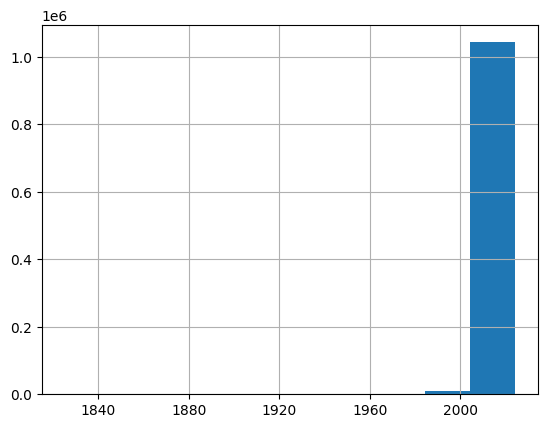

In [3]:
#pd.to_datetime(df['publish_time'])
#   publish_time列を日付として認識させる
#年だけのやつがあるからパニックった。→format='mixed'を追加
df['publish_time'] = pd.to_datetime(df['publish_time'],format='mixed')
#公開時間列の、ヒストグラムを描画する機能を実行する
df['publish_time'].hist()

Interestingly, there are coronavirus-related papers that date back to 1880!
back to までさかのぼる

Structured Data Extraction
Let's see what kind of information we can easily extract from abstracts. One thing we might be interested in is to see which treatment strategies exist, and how they evolved over time. To begin with, we can manually compile the list of possible medications used to treat COVID, and also the list of diagnoses. We then go over them and search corresponding terms in the abstracts of papers.
abstracts概要
To begin with意味
possible 
evolve進化
go over全体をチェックする
corresponding対応する

In [4]:
#該当するものを捕まえる虫取り網の作成
medications = [
    'hydroxychloroquine', 'chloroquine', 'tocilizumab', 'remdesivir', 'azithromycin', 
    'lopinavir', 'ritonavir', 'dexamethasone', 'heparin', 'favipiravir', 'methylprednisolone']
#diagnosis診断名
diagnosis = [
    'covid','sars','pneumonia','infection','diabetes','coronavirus','death'
]

#df['abstract'].apply(...)
#   abstract列を上から1行ずつ、全部チェックしていくよ！
#lambda x:
#   ミニ関数
#str(x)
#   念のため、すべて文字列（テキスト）にする、空っぽ（NaN）」や「数字」が混ざっているから
for m in medications:
    print(f" + Processing medication: {m}")
    #str(x)
    #'NaN' や '2020'に変換してくれる
    #.lower()
    #小文字にする
    #count(' '+m)
    #スペースを入れて探す、にている名前の薬があるため
    df[m] = df['abstract'].apply(lambda x: str(x).lower().count(' '+m))
    
for m in diagnosis:
    print(f" + Processing diagnosis: {m}")
    df[m] = df['abstract'].apply(lambda x: str(x).lower().count(' '+m))

 + Processing medication: hydroxychloroquine
 + Processing medication: chloroquine
 + Processing medication: tocilizumab
 + Processing medication: remdesivir
 + Processing medication: azithromycin
 + Processing medication: lopinavir
 + Processing medication: ritonavir
 + Processing medication: dexamethasone
 + Processing medication: heparin
 + Processing medication: favipiravir
 + Processing medication: methylprednisolone
 + Processing diagnosis: covid
 + Processing diagnosis: sars
 + Processing diagnosis: pneumonia
 + Processing diagnosis: infection
 + Processing diagnosis: diabetes
 + Processing diagnosis: coronavirus
 + Processing diagnosis: death


We have added a bunch of columns to our dataframe that contain number of times a given medicine/diagnosis is present in the abstract.

Note that we add space to the beginning of the word when looking for a substring. If we do not do that, we might get wrong results, because chloroquine would also be found inside substring hydroxychloroquine. Also, we force conversion of abstracts column to str to get rid of an error - try removing str and see what happens.

To make working with data easier, we can extract the sub-frame with only medication counts, and compute the accumulated number of occurrences. This gives is the most popular medication:
a bunch of 〜一房の
substring文章の一部
conversion変換
str文字列
accumulated蓄積した

In [5]:
dfm = df[medications]
#sum
#名前ごとに分けて合計してくれる、表の形は崩れる
#.reset_index()
#表の形にする。
#.rename(columns={ 'index' : 'Name', 0 : 'Count'})
#index→Name,0→Count
dfm = dfm.sum().reset_index().rename(columns={ 'index' : 'Name', 0 : 'Count'})

dfm.sort_values('Count',ascending=False)

,Name,Count
0,hydroxychloroquine,11157
3,remdesivir,10680
2,tocilizumab,7914
8,heparin,5563
1,chloroquine,5222
7,dexamethasone,5110
4,azithromycin,4352
5,lopinavir,4315
9,favipiravir,3358
10,methylprednisolone,2346


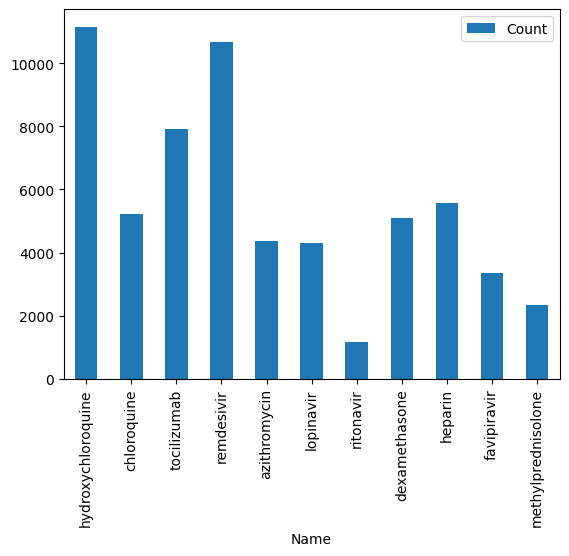

In [6]:
from matplotlib import pyplot as plt
#set_index('Name')
#   グラフの名前ラベルを横軸にセット
dfm.set_index('Name').plot(kind='bar')
plt.show()

Looking for Trends in Treatment Strategy
In the example above we have summed all values, but we can also do the same on a monthly basis:

In [7]:
dfm = df[['publish_time']+medications].set_index('publish_time')
dfm = dfm[(dfm.index>="2020-01-01") & (dfm.index<="2021-07-31")]
dfmt = dfm.groupby([dfm.index.year,dfm.index.month]).sum()
dfmt

hydroxychloroquine  chloroquine  tocilizumab  \
publish_time publish_time                                                 
2020         1                           3885         1976         1911   
             2                              0           19            0   
             3                             46           73            5   
             4                            186          236           49   
             5                            450          188          158   
             6                            381          149          243   
             7                            379          176          204   
             8                            313          115          175   
             9                            318          124          188   
             10                           311           96          210   
             11                           267           66          169   
             12                           254          108          228   
2021         1                           2467          882         2165   
             2                            165           66          184   
             3                            175           86          189   
             4                            200           71          129   
             5                            152           55          139   
             6                            144           30          146   
             7                            115           45           96   

                           remdesivir  azithromycin  lopinavir  ritonavir  \
publish_time publish_time                                                   
2020         1                   2280          1226       1549        403   
             2                      3             3         18         11   
             3                     29            12         52         16   
             4                    122            69        113         13   
             5                    209           128        134         41   
             6                    186           110        132         18   
             7                    174           108        138         29   
             8                    173           148         93         24   
             9                    190            90         97         28   
             10                   227            93        126         39   
             11                   202            77        106         27   
             12                   267            98         75         30   
2021         1                   2877          1072        932        216   
             2                    180            90         76          9   
             3                    301            89        101         18   
             4                    167            89         60         13   
             5                    182            71         56         22   
             6                    180            75         47         14   
             7                    252            83         52          4   

                           dexamethasone  heparin  favipiravir  \
publish_time publish_time                                        
2020         1                       598     1027          730   
             2                         1        3           12   
             3                         3       18           11   
             4                        14       80           48   
             5                        12       93           48   
             6                        48       84           30   
             7                        58      116           56   
             8                        56       96           46   
             9                        90      113           46   
             10                      101      117           82   
             11                       84 

This gives us a good picture of treatment strategies. Let's visualize it!

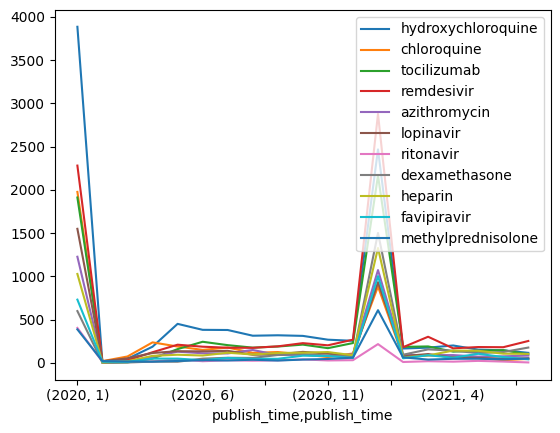

In [8]:
dfmt.plot()
plt.show()

An interesting observation is that we have huge spikes at two locations: January, 2020 and January, 2021. It is caused by the fact that some papers do not have a clearly specified data of publication, and they are specified as January of the respective year.

To make more sense of the data, let's visualize just a few medicines. We will also "erase" data for January, and fill it in by some medium value, in order to make nicer plot:
huge spikes巨大なトゲ

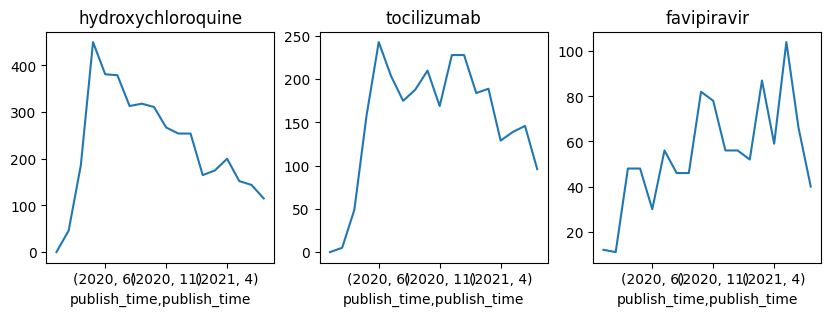

In [ ]:
import numpy as np
meds = ['hydroxychloroquine','tocilizumab','favipiravir']
#Nanと表示したいときはnumpy ,これにすると計算スピードが落ちない
dfmt.loc[(2020,1)] = np.nan
dfmt.loc[(2021,1)] = np.nan
#穴が開いている箇所を満たす
dfmt.ffill(inplace=True)
#横一列に三個のデータのグラフの枠を並べて10x3の画用紙を作って
#全体のグラフの構成
fig, ax = plt.subplots(1,len(meds),figsize=(10,3))
#enumerate()二つの戻り値をくれる　indexと中身
#アクシズの定義
for i,m in enumerate(meds):
    dfmt[m].plot(ax=ax[i])
    ax[i].set_title(m)
plt.show()

Observe how popularity of hydroxychloroquine was on the rise in the first few months, and then started to decline, while number of mentions of favipiravir shows stable rise. Another good way to visualize relative popularity is to use stack plot (or area plot in Pandas terminology):
on the rise上昇傾向がある
while一方で
stack plot積み上げグラフ

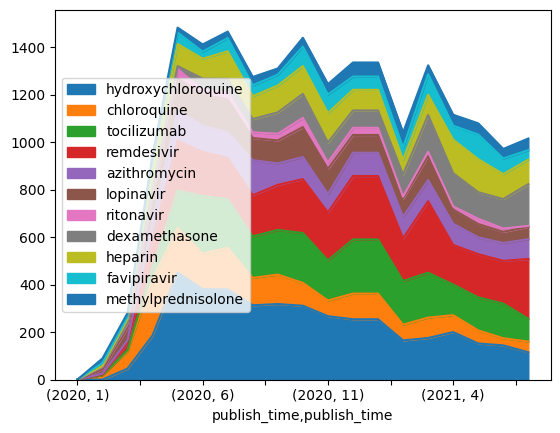

In [ ]:
#エリアプロット、積み上げていく、相対的な人気の可視化に優れている
]dfmt.plot.area()
plt.show()

Even further, we can compute relative popularity in percents:
even furtherさらに進んで

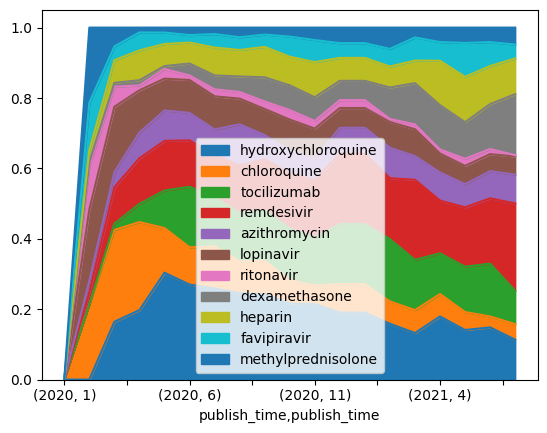

In [ ]:
#[:,:]
#すべての行指定
#pandasはindexは特別扱いなので計算に含めない
dfmtp = dfmt.iloc[:,:].apply(lambda x: x/x.sum(), axis=1)
dfmtp.plot.area()
plt.show()

Computing Medicine-Diagnosis Correspondence
One of the most interesting relationships we can look for is how different diagnoses are treated with different medicines. In order to visualize it, we need to compute co-occurence frequency map, which would show how many times two terms are mentioned in the same paper.

Such a map is essentially a 2D matrix, which is best represented by numpy array. We will compute this map by walking through all abstracts, and marking entities that occur there:
Correspondence対応
Relationship関係
numpy array　numpy配列
terms用語

In [ ]:
m = np.zeros((len(medications),len(diagnosis)))#np.zerosは0で埋めすくされた方眼紙を用意して、(縦、横)
for a in df['abstract']:#全体表からab列を抽出して一個ずつaにいれる
    x = str(a).lower()#aをテキストにして小文字にする
    for i,d in enumerate(diagnosis):#病名のリストを取り出し戻り値i(index)、元のやつに分ける
        if ' '+d in x:#もしabの文字列がはじめがスペースならfor文へ
            for j,me in enumerate(medications):#薬のリストから一個ずつとりだして戻り値i(index)、元のやつに分ける
                if ' '+me in x:#もし薬の名前に初めにスペースがあれば次へ                   
                    m[j,i] += 1#ある論文に病気名、薬名が含まれているとき＋1点

In [18]:
m

array([[5470., 2585.,  812., 2381.,  387., 3036., 1081.],
       [2376., 1381.,  258., 1077.,   90., 1555.,  408.],
       [2738., 1007.,  833., 1343.,  236., 1333.,  678.],
       [4284., 2804.,  720., 2076.,  241., 2677.,  817.],
       [2163.,  928.,  476., 1066.,  180., 1032.,  481.],
       [2244., 1239.,  424.,  976.,  122., 1495.,  406.],
       [ 594.,  429.,   87.,  301.,   23.,  409.,  123.],
       [2164.,  919.,  521., 1113.,  180., 1019.,  463.],
       [2035.,  877.,  428.,  999.,  137.,  996.,  365.],
       [1257.,  791.,  250.,  565.,   55.,  804.,  173.],
       [1008.,  476.,  399.,  574.,  100.,  582.,  205.]])